<h1 style="background-color:orange;font-family:newtimeroman;font-size:350%;text-align:center;border-radius: 15px 50px;">BANK CHURN PREDICTION</h1>


## 📋 Project Description

Customer churn — when a bank customer closes their account or stops using their credit card — is one of the costliest problems a bank can face, since acquiring a new customer is far more expensive than retaining an existing one. This project analyzes real credit-card customer records to understand **why customers leave** and to build a **machine learning model that predicts churn before it happens**.

**Dataset:** ~10,000 bank customers with 20 features covering demographics (age, gender, income, education, marital status), account details (card category, credit limit, months on book), and behavior (transaction amount/count, relationship count, inactivity).

**Goals:**
- Explore and visualize the key demographic and behavioral patterns in the data (EDA).
- Preprocess and balance the data (encoding, SMOTE oversampling, PCA).
- Train and compare multiple classification models (KNN, SVM, Random Forest, Logistic Regression).
- Combine the best models into a final Voting Classifier and evaluate performance with confusion matrices and ROC curves.

**Why it matters:** identifying at-risk customers early lets the business proactively improve service and retention offers for exactly the customers who need it, rather than treating everyone the same way.

In this project, I perform a classification analysis on customer records from a bank database. The aim is to identify the key factors contributing to customer attrition in a consumer credit card portfolio and to develop a classification model that can accurately predict customers who are likely to churn. By understanding the patterns and behaviors that lead to attrition, the business can proactively intervene and improve customer retention.


## 1. Libraries And Utilities

Imports necessary libraries (including `imbalanced-learn`'s `SMOTE`) and sets a global plotting theme.

Installs `imbalanced-learn`, which provides the `SMOTE` implementation used below to balance the training set (Section 4.2).

In [2]:
!pip install imbalanced-learn


In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import roc_curve
import seaborn as sns
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# --- Global plotting theme: a clean, colourful, consistent look for every chart ---
PALETTE = ["#FF6B6B", "#4ECDC4", "#FFD93D", "#6A4C93",
           "#1A8FE3", "#FF9F1C", "#2EC4B6", "#E84393"]

sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.edgecolor": "#CCCCCC",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.titlepad": 12,
    "figure.titlesize": 18,
    "figure.titleweight": "bold",
})


## 2. Data Loading

This cell loads the `BankChurners.csv` dataset, removes the last two unnecessary columns, and then displays the first 5 rows and the shape of the DataFrame to provide an initial overview of the data.

In [4]:
data = pd.read_csv('BankChurners.csv')
data = data[data.columns[:-2]]
display(data.head())

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


Provides a concise summary of the DataFrame, including data types, non-null values, and memory usage, to identify missing values and understand column types.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

Visualizes the `Customer_Age` distribution using a boxplot and a histogram with KDE to understand age demographics.

### 2.1 About Data

#### Data set includes information about:

*   **Customers who Attrited** – the column is called Churn
*   **Services that each customer using** – Type of credit Card , Total no. of products held by the customer.
*   **Customer credit information** - how long they’ve been a customer, No. of months inactive in the last 12 months, Credit Limit on the Credit Card, Total Revolving Balance on the Credit Card, Open to Buy Credit Line (Average of last 12 months), Total Transaction Amount ,Total Transaction Count and Average Card Utilization Ratio.
*   **Demographic info about customers** – gender,income range, age, and if they have partners and dependents

The data contains no missing values. Demographic columns are categorical, requiring encoding and standardization of numerical values.

## 3. Exploratory Data Analysis

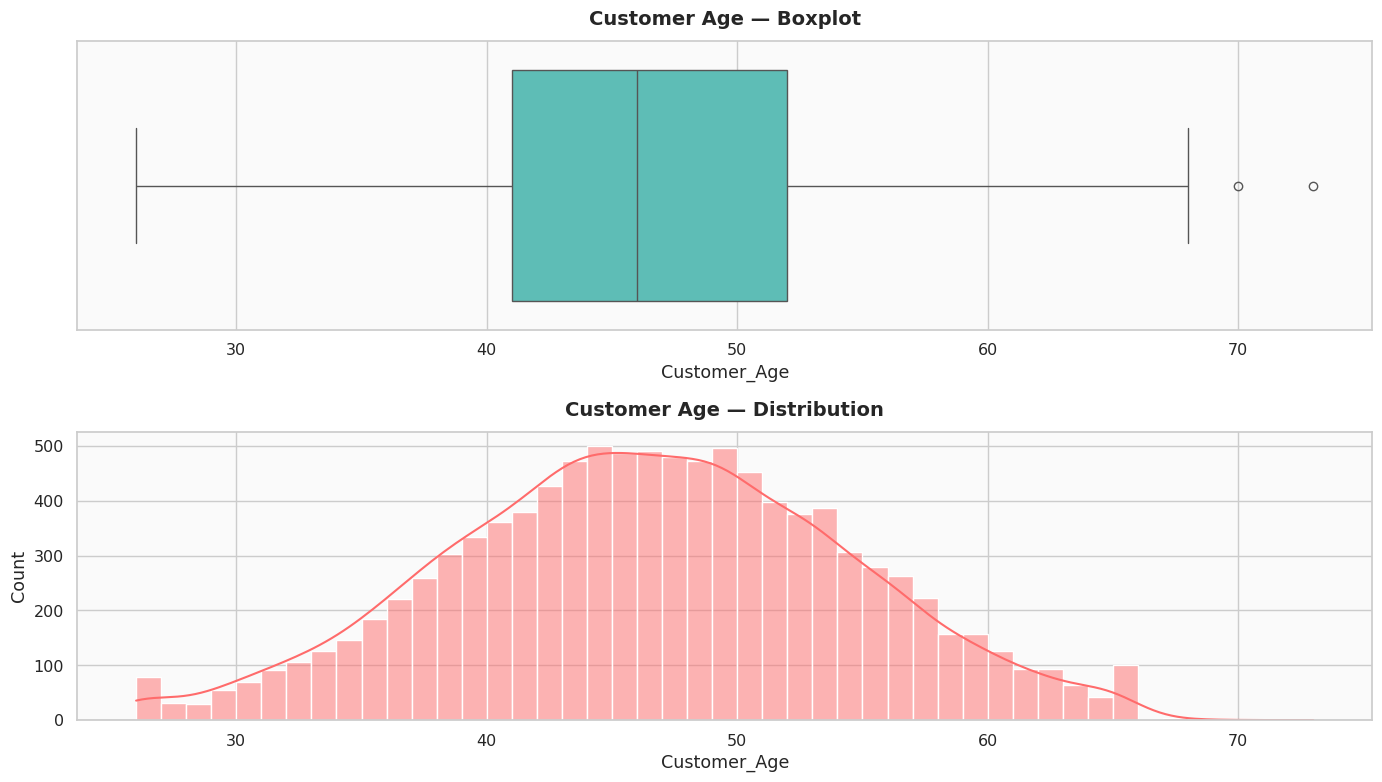

In [6]:
f, ax = plt.subplots(2, 1, figsize=(14, 8))
ax1, ax2 = ax.ravel()

sns.boxplot(x=data['Customer_Age'], ax=ax1, color="#4ECDC4")
ax1.set_title('Customer Age — Boxplot')

sns.histplot(x=data['Customer_Age'], ax=ax2, color="#FF6B6B", kde=True, edgecolor="white")
ax2.set_title('Customer Age — Distribution')

plt.tight_layout()
plt.show()


Observation: Customer age distribution follows a normal distribution, allowing for normality assumption in further analysis.

Generates three pie charts to visualize gender distribution: overall, for platinum cardholders, and for blue cardholders.

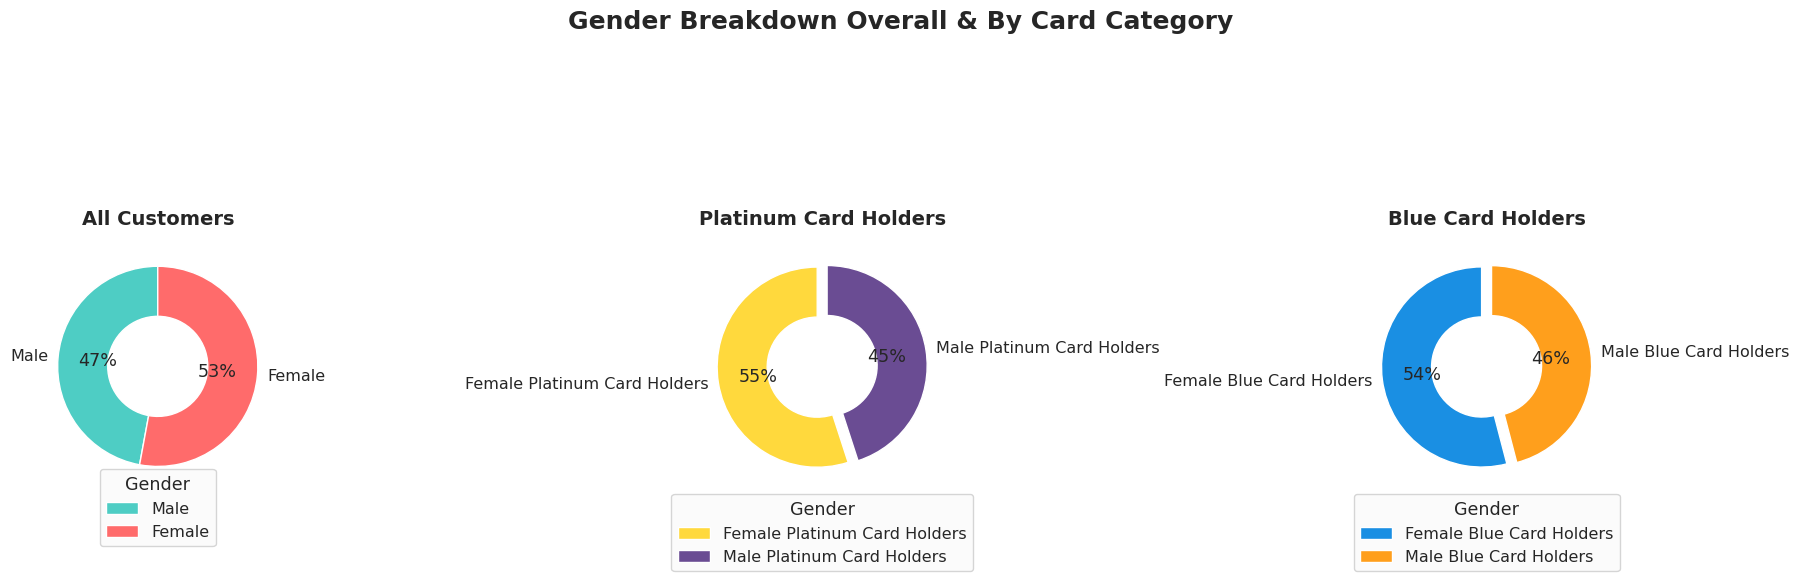

In [7]:
labels1 = ['Male', 'Female']
sizes1 = data.value_counts('Gender').iloc[1], data.value_counts('Gender').iloc[0]

labels2 = ['Female Platinum Card Holders', 'Male Platinum Card Holders']
sizes2 = data.query('Card_Category=="Platinum"').Gender.value_counts().values

labels3 = ['Female Blue Card Holders', 'Male Blue Card Holders']
sizes3 = data.query('Card_Category=="Blue"').Gender.value_counts().values

# Create a figure with three subplots in one row
fig, ax = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Gender Breakdown Overall & By Card Category", y=1.03)
ax1, ax2, ax3 = ax.ravel()

# Plot Pie Chart 1
wedges, texts, autotexts = ax1.pie(
    sizes1, labels=labels1, colors=["#4ECDC4", "#FF6B6B"],
    startangle=90, autopct='%.0f%%', wedgeprops=dict(width=0.5, edgecolor='white')
)
ax1.set_title("All Customers")
ax1.legend(wedges, labels1, title="Gender", loc="lower center", bbox_to_anchor=(0.5, -0.25))

# Plot Pie Chart 2
wedges, texts, autotexts = ax2.pie(
    sizes2, labels=labels2, colors=["#FFD93D", "#6A4C93"],
    startangle=90, explode=[0.05, 0.05], autopct='%.0f%%',
    wedgeprops=dict(width=0.5, edgecolor='white')
)
ax2.set_title("Platinum Card Holders")
ax2.legend(wedges, labels2, title="Gender", loc="lower center", bbox_to_anchor=(0.5, -0.35))

# Plot Pie Chart 3
wedges, texts, autotexts = ax3.pie(
    sizes3, labels=labels3, colors=["#1A8FE3", "#FF9F1C"],
    startangle=90, explode=[0.05, 0.05], autopct='%.0f%%',
    wedgeprops=dict(width=0.5, edgecolor='white')
)
ax3.set_title("Blue Card Holders")
ax3.legend(wedges, labels3, title="Gender", loc="lower center", bbox_to_anchor=(0.5, -0.35))

# Adjust layout to avoid overlapping
plt.tight_layout()

# Display the plot
plt.show()


Creates three pie charts showing the proportions of `Income_Category`, `Education_Level`, and `Attrition_Flag` to understand demographic and churn status distributions.

Observation: Gender distribution is nearly uniform, with a slightly higher percentage of females, but not statistically significant.

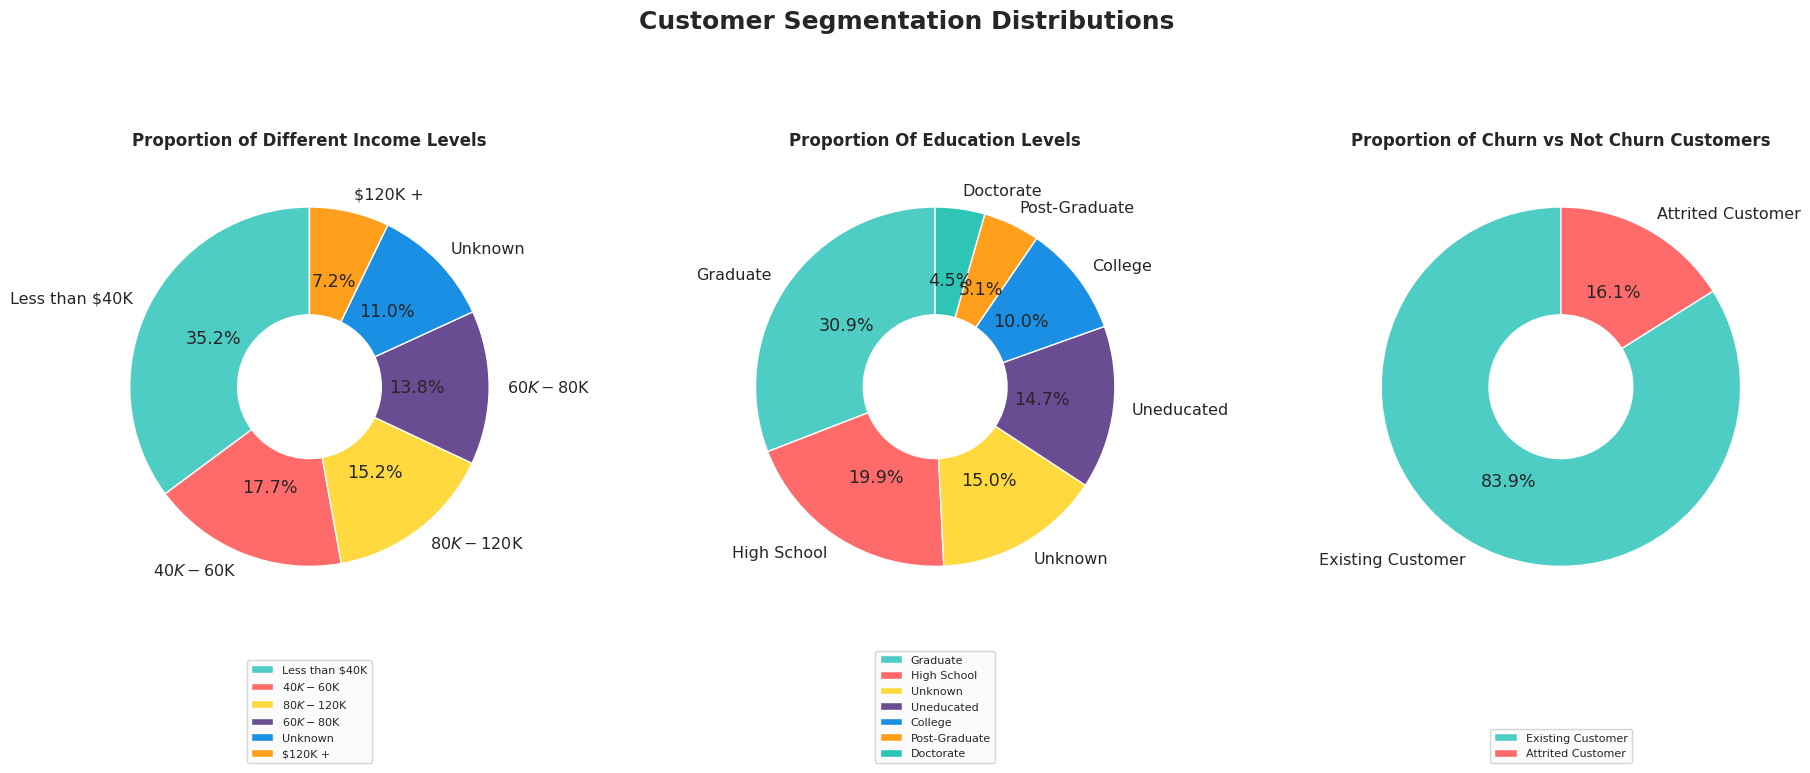

In [8]:
# List of categories to plot and titles
categories = [
    ('Income_Category', 'Proportion of Different Income Levels'),
    ('Education_Level', 'Proportion Of Education Levels'),
    ('Attrition_Flag', 'Proportion of Churn vs Not Churn Customers')
]

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(19, 7))
fig.suptitle("Customer Segmentation Distributions", y=1.05)

CB_PALETTE = ["#4ECDC4", "#FF6B6B", "#FFD93D", "#6A4C93", "#1A8FE3", "#FF9F1C", "#2EC4B6"]

# Plot each pie chart
for i, (column, title) in enumerate(categories):
    ax = axs[i]

    # Get value counts for the column
    counts = data[column].value_counts()

    colors = CB_PALETTE[:len(counts)]

    wedges, texts, autotexts = ax.pie(
        counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
        wedgeprops={'width': 0.6, 'edgecolor': 'white'}, colors=colors
    )

    ax.set_title(title, fontsize=12)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), fontsize=8)

# leave space for title and legend
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()


Generates two pie charts to show the distribution of `Marital_Status` and `Card_Category`.

Observation: Over 70% of customers have formal education. With only 16% churn customers, SMOTE will be used to upsample the minority class for better model training.

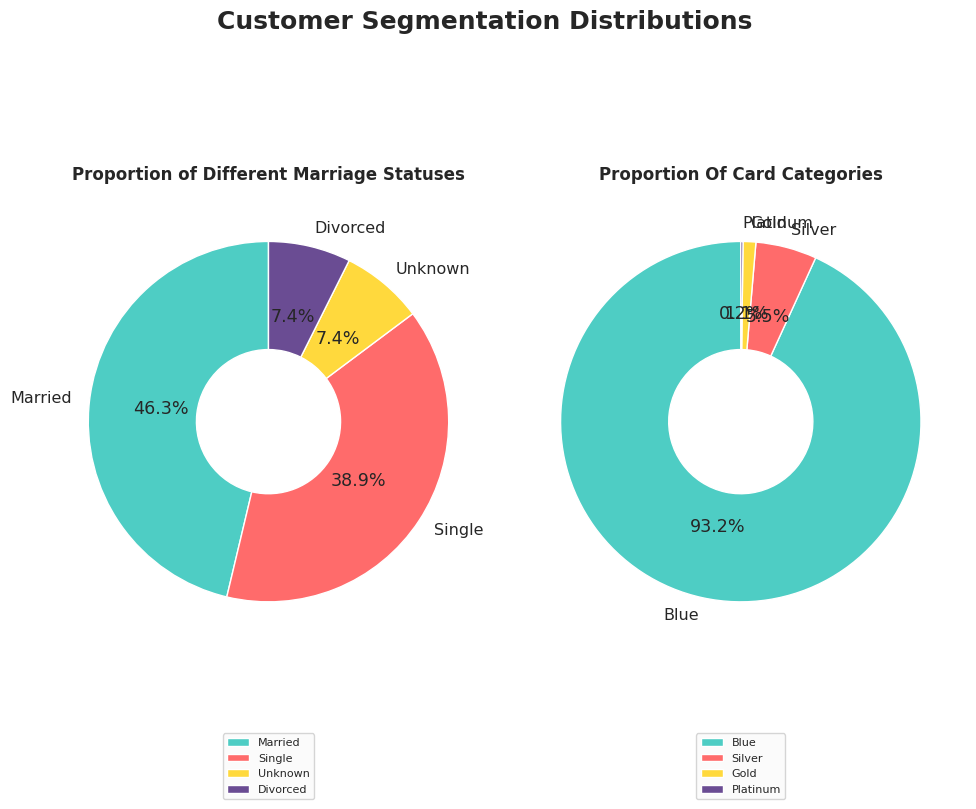

In [9]:
# List of categories to plot and titles
categories = [
    ('Marital_Status', 'Proportion of Different Marriage Statuses'),
    ('Card_Category', 'Proportion Of Card Categories'),
]

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 7))
fig.suptitle("Customer Segmentation Distributions", y=1.05)

CB_PALETTE = ["#4ECDC4", "#FF6B6B", "#FFD93D", "#6A4C93", "#1A8FE3", "#FF9F1C"]

# Plot each pie chart
for i, (column, title) in enumerate(categories):
    ax = axs[i]

    # Get value counts for the column
    counts = data[column].value_counts()

    colors = CB_PALETTE[:len(counts)]

    wedges, texts, autotexts = ax.pie(
        counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
        wedgeprops={'width': 0.6, 'edgecolor': 'white'}, colors=colors
    )
    ax.set_title(title, fontsize=12)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), fontsize=8)

# leave space for title and legend
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()


Displays the `Dependent_count` distribution using a boxplot and a histogram with KDE.

Observation: Approximately half of customers are married, and nearly the other half are single. A small percentage (7%) are divorced.

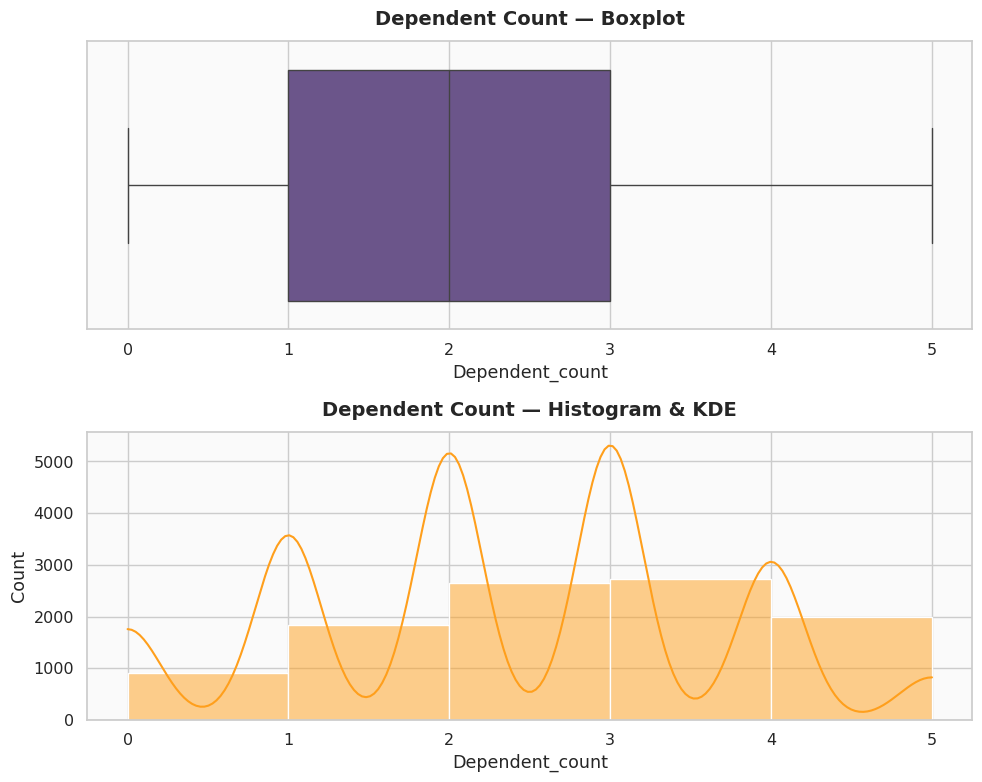

In [10]:
# Initialize the figure and axes layout
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax1, ax2 = ax.ravel()

# Plot the upper panel: Boxplot
sns.boxplot(x=data["Dependent_count"], ax=ax1, color="#6A4C93")
ax1.set_title("Dependent Count — Boxplot")

# Plot the lower panel: Histogram and KDE
sns.histplot(
    x=data["Dependent_count"],
    ax=ax2,
    color="#FF9F1C",
    bins=5,
    kde=True,
    edgecolor="white",
)
ax2.set_title("Dependent Count — Histogram & KDE")

# Clean up spacing and display the plot
plt.tight_layout()
plt.show()


Visualizes the `Months_on_book` feature with a boxplot and a histogram.

Observation: The `Dependent_count` distribution is fairly normally distributed with a slight right skew.

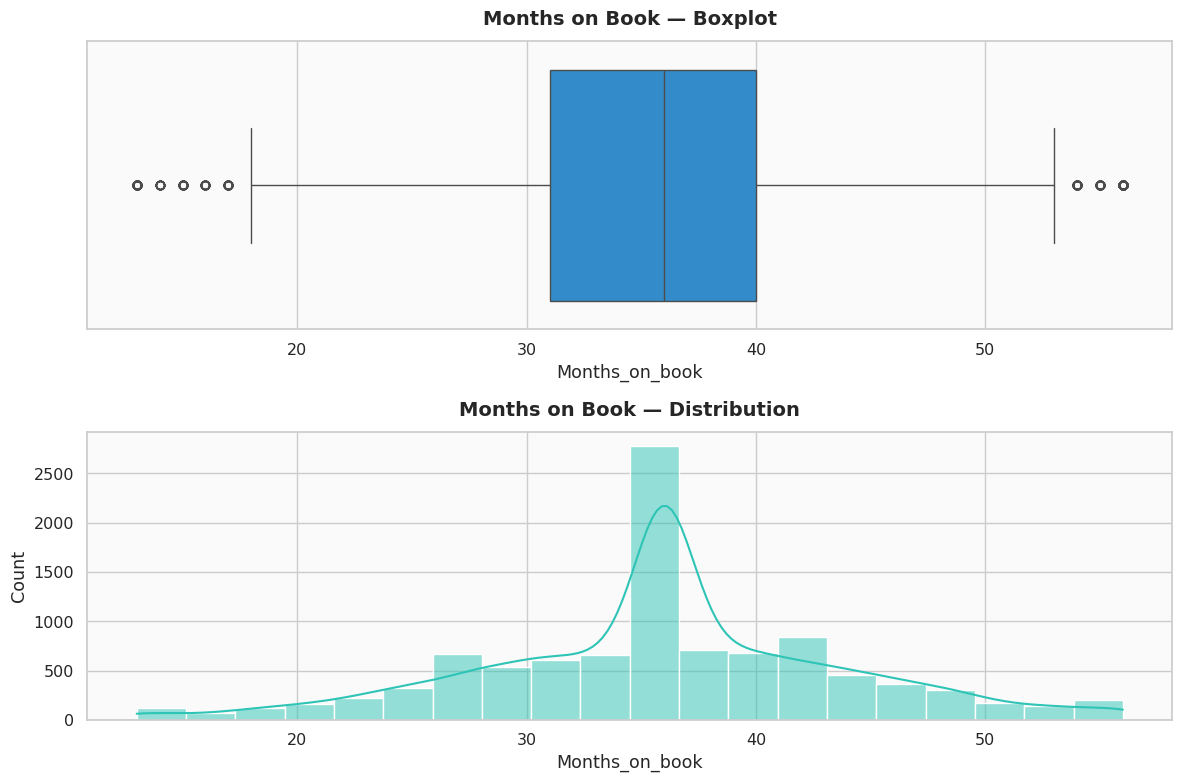

In [11]:
# Initialize layout
f, ax = plt.subplots(2, 1, figsize=(12, 8))
ax1, ax2 = ax.ravel()

# Upper panel: Boxplot
sns.boxplot(x=data["Months_on_book"], ax=ax1, color="#1A8FE3")
ax1.set_title("Months on Book — Boxplot")

# Lower panel: Histogram & Distribution curve
sns.histplot(
    x=data["Months_on_book"],
    ax=ax2,
    color="#2EC4B6",
    bins=20,
    kde=True,
    edgecolor="white",
)
ax2.set_title("Months on Book — Distribution")

# Render
plt.tight_layout()
plt.show()


Observation: The `Months_on_book` distribution is left-skewed, indicating more long-term customers.

Visualizes the `Total_Relationship_Count` distribution using a boxplot and a histogram with KDE.

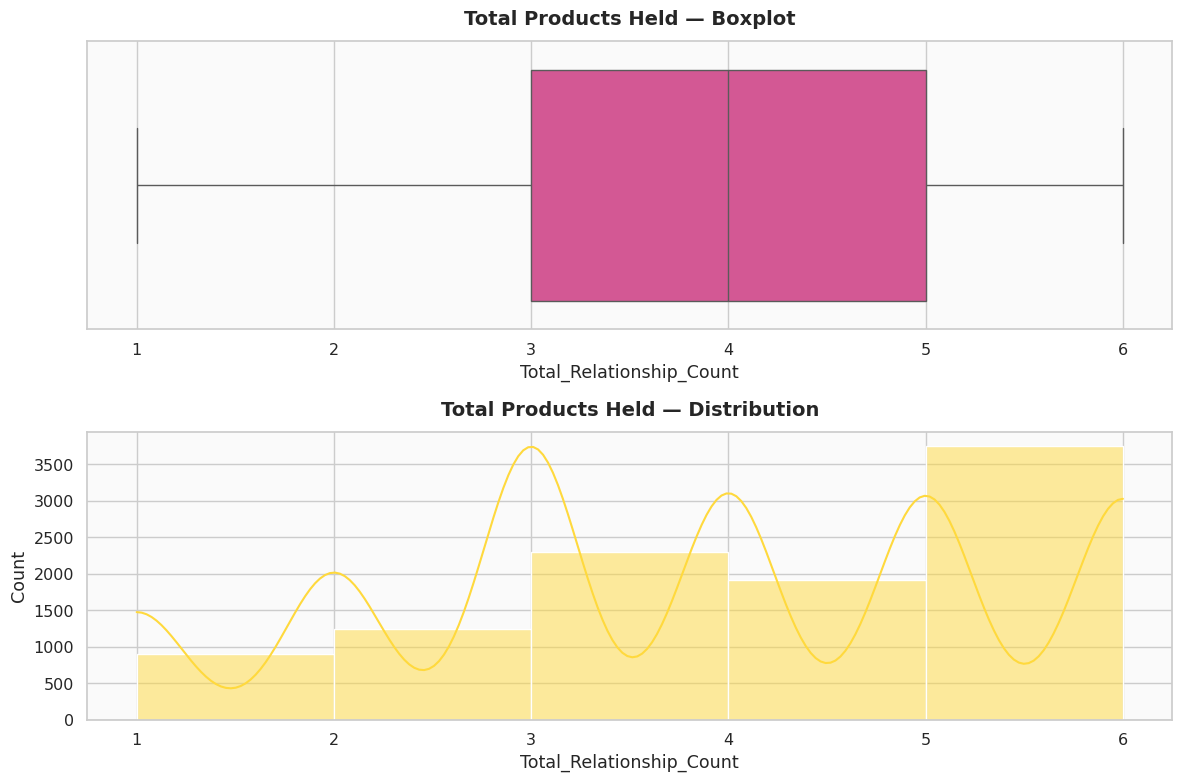

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax1, ax2 = ax.ravel()

sns.boxplot(x=data['Total_Relationship_Count'], ax=ax1, color="#E84393")
ax1.set_title('Total Products Held — Boxplot')

sns.histplot(x=data['Total_Relationship_Count'], ax=ax2, color="#FFD93D", bins=5, kde=True, edgecolor="white")
ax2.set_title('Total Products Held — Distribution')

plt.tight_layout()
plt.show()


Displays the `Total_Trans_Amt` distribution (last 12 months) using a boxplot and a histogram with KDE.

Observation: The distribution of `Total_Relationship_Count` appears uniform, suggesting it may not be a strong predictor for churn.

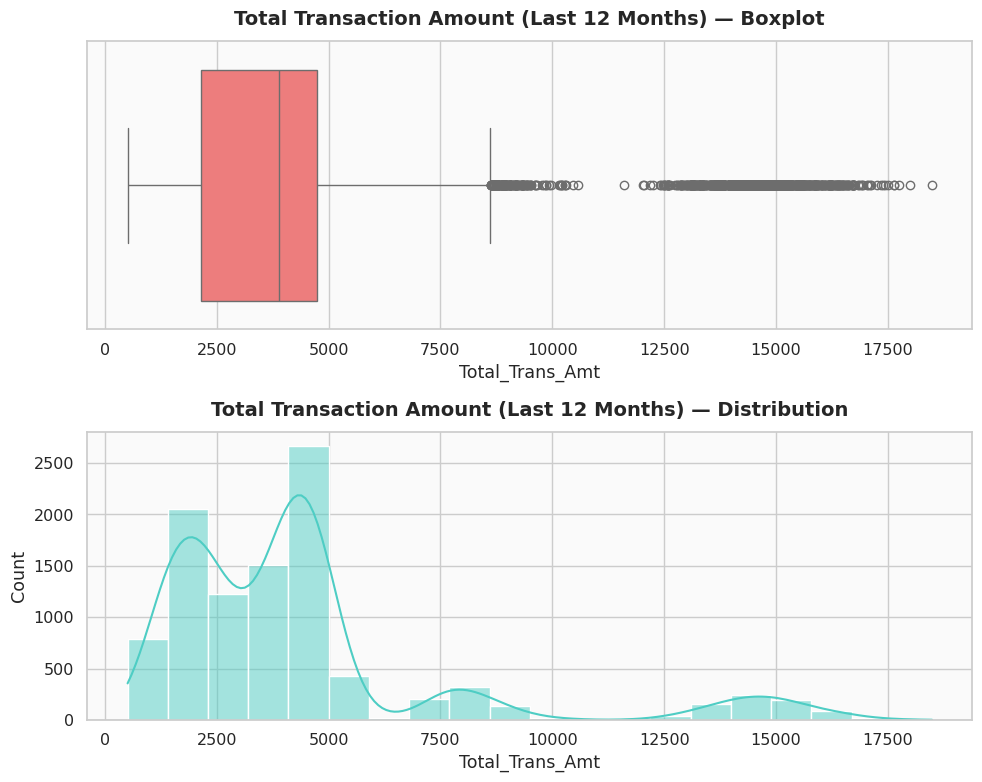

In [13]:
f, ax = plt.subplots(2, 1, figsize=(10, 8))
ax1, ax2 = ax.ravel()

sns.boxplot(x=data['Total_Trans_Amt'], ax=ax1, color="#FF6B6B")
ax1.set_title('Total Transaction Amount (Last 12 Months) — Boxplot')

sns.histplot(x=data['Total_Trans_Amt'], ax=ax2, color="#4ECDC4", bins=20, kde=True, edgecolor="white")
ax2.set_title('Total Transaction Amount (Last 12 Months) — Distribution')

plt.tight_layout()
plt.show()


Preprocesses the data by label encoding `Attrition_Flag` and `Gender`, one-hot encoding other categorical features (dropping 'Unknown'/'Platinum' to avoid multicollinearity), and removing original categorical columns and `CLIENTNUM`.

Observation: `Total_Trans_Amt` shows a multimodal distribution, indicating underlying customer groups. Clustering could reveal similarities and differences between these groups.

## 4. Data Preprocessing

In [14]:
print("--- BEFORE PREPROCESSING ---")
print(data.columns.tolist())

# Apply your preprocessing steps
data.Attrition_Flag = data.Attrition_Flag.replace(
    {"Attrited Customer": 1, "Existing Customer": 0}
).astype(int)

data.Gender = data.Gender.replace({"F": 1, "M": 0}).astype(int)

data = pd.concat(
    [
        data,
        pd.get_dummies(data["Education_Level"]).drop(columns=["Unknown"]),
    ],
    axis=1,
)
data = pd.concat(
    [data, pd.get_dummies(data["Income_Category"]).drop(columns=["Unknown"])],
    axis=1,
)
data = pd.concat(
    [data, pd.get_dummies(data["Marital_Status"]).drop(columns=["Unknown"])],
    axis=1,
)
data = pd.concat(
    [data, pd.get_dummies(data["Card_Category"]).drop(columns=["Platinum"])],
    axis=1,
)

data.drop(
    columns=[
        "Education_Level",
        "Income_Category",
        "Marital_Status",
        "Card_Category",
        "CLIENTNUM",
    ],
    inplace=True,
)

print("\n--- AFTER PREPROCESSING ---")
print(data.columns.tolist())

--- BEFORE PREPROCESSING ---
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

--- AFTER PREPROCESSING ---
['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'College', 'Doctorate', 'Graduate', 'High School', 'Post-Graduate', 'Uneducated', '$120K +', '$40K - $60K', '$60K - $80K', '$80K - $120K', 'Less than $40K', 'Divorced', 'Married', 'Single', 'Blue', 'G

Generates a heatmap to visualize the correlation matrix of raw features post-preprocessing.

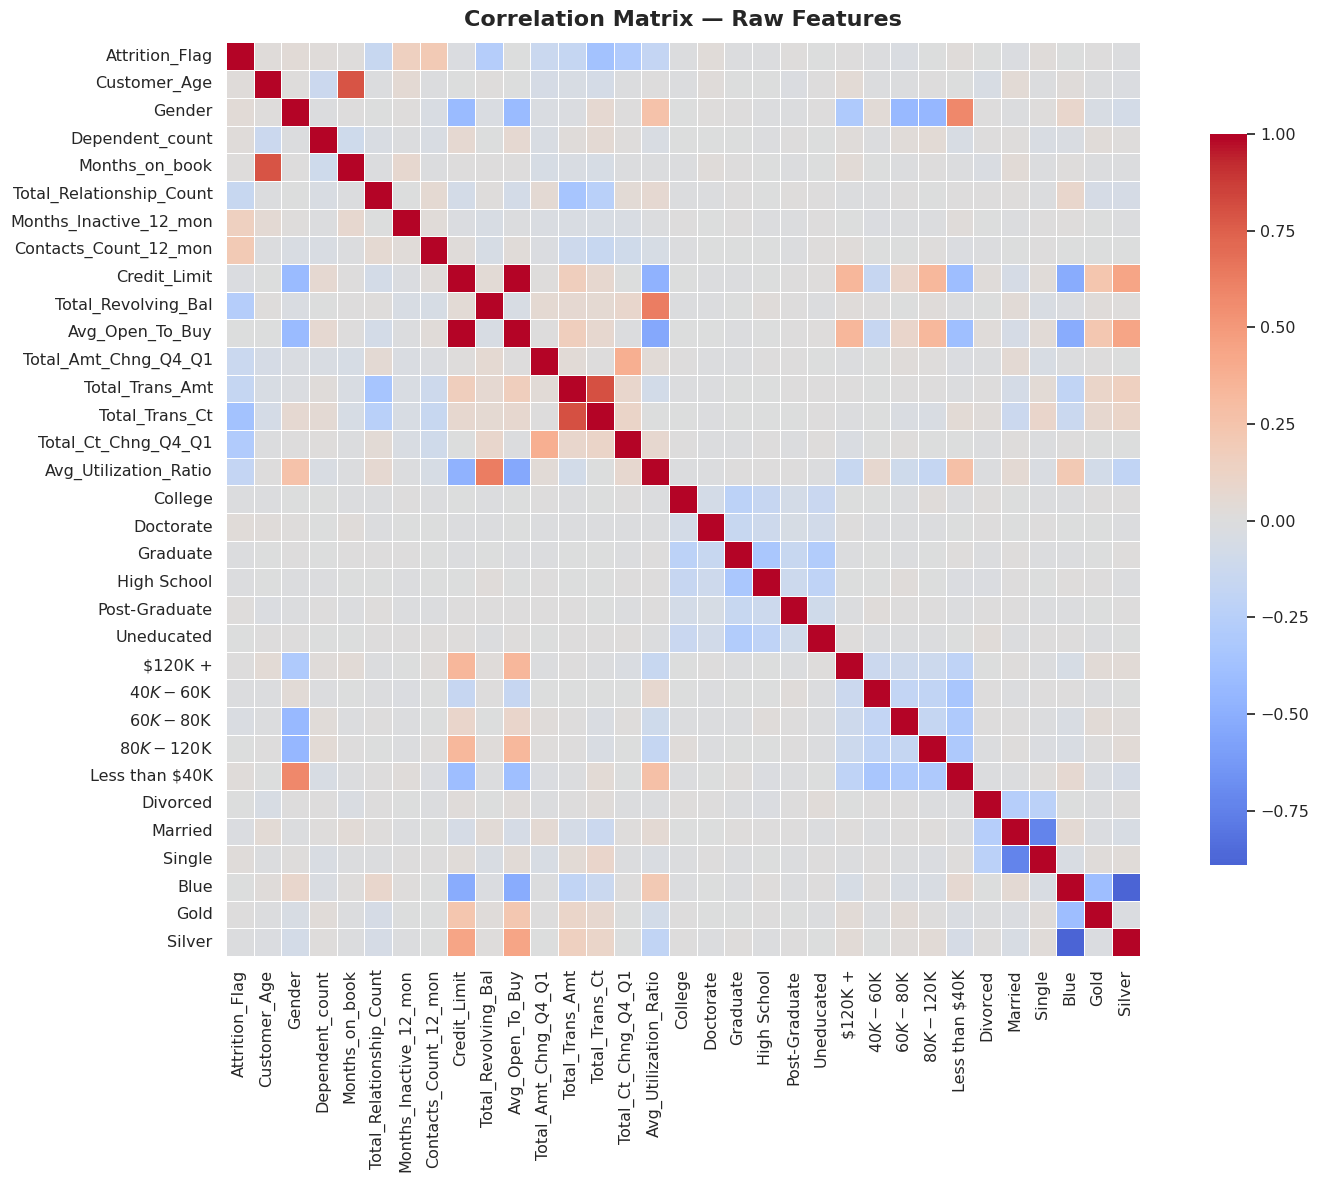

In [15]:
# Setup the figure space
plt.figure(figsize=(16, 12))

# Calculate the mathematical correlation matrix
corrmap = data.corr(numeric_only=True)

# Generate the structured heatmap plot
sns.heatmap(
    corrmap,
    cmap="coolwarm",
    linewidths=0.5,
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)

# Set titles and display layout
plt.title("Correlation Matrix — Raw Features", fontsize=16)
plt.tight_layout()
plt.show()


Observation: `Customer_Age` correlates with `Months_on_book`. `Credit_Limit`, `Total_Trans_Amt`, and `Total_Trans_Ct` show positive correlations. `Total_Revolving_Bal` and `Avg_Utilization_Ratio` are negatively correlated with `Credit_Limit`. `Months_Inactive_12_mon` and `Contacts_Count_12_mon` are positively correlated. `Attrition_Flag` negatively correlates with `Total_Trans_Amt` and `Total_Trans_Ct`.

### 4.1 Train-Test Split (Before Balancing)

Splits the raw, encoded dataset into training and testing sets **before** any oversampling. This is done so the test set keeps the real, imbalanced class distribution and so that no synthetic SMOTE sample can end up split across both the training and testing sets (which would leak information and inflate the evaluation metrics).

In [16]:
X_raw = data.drop(columns=["Attrition_Flag"])
y_raw = data["Attrition_Flag"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print("--- RAW TRAIN/TEST SPLIT (BEFORE SMOTE) ---")
print(f"Training rows: {X_train_raw.shape[0]}")
print(f"Testing rows : {X_test_raw.shape[0]}")
print(f"\nTraining class balance:\n{y_train_raw.value_counts()}")
print(f"\nTesting class balance:\n{y_test_raw.value_counts()}")

--- RAW TRAIN/TEST SPLIT (BEFORE SMOTE) ---
Training rows: 8101
Testing rows : 2026

Training class balance:
Attrition_Flag
0    6799
1    1302
Name: count, dtype: int64

Testing class balance:
Attrition_Flag
0    1701
1     325
Name: count, dtype: int64


### 4.2 Data Upsampling Using SMOTE (Training Set Only)

**SMOTE** (Synthetic Minority Over-sampling Technique) balances class distribution by creating synthetic minority-class examples. It is applied here to the **training set only** — the test set is left at its original, real-world class balance so that evaluation metrics reflect genuine model performance rather than being inflated by synthetic points leaking across the train/test boundary.

In [17]:
print(f"Training class balance before SMOTE:\n{y_train_raw.value_counts()}\n")

# Initialize and run SMOTE on the training data only
oversample = SMOTE(random_state=42)
X_train_res, y_train_res = oversample.fit_resample(X_train_raw, y_train_raw)

# Combine resampled training features and target back into a single DataFrame
usampled_df = X_train_res.assign(Churn=y_train_res)
# Print using the consistent name
print(f"Training class balance after SMOTE:\n{usampled_df['Churn'].value_counts()}")



Training class balance before SMOTE:
Attrition_Flag
0    6799
1    1302
Name: count, dtype: int64

Training class balance after SMOTE:
Churn
0    6799
1    6799
Name: count, dtype: int64


Separates the one-hot encoded (OHE) categorical columns into `ohe_data` (from the SMOTE-balanced training set) and `ohe_data_test` (from the untouched test set), so PCA can be fit on the training data only and then applied consistently to the test data.

In [18]:
print("--- BEFORE ISOLATION ---")
print(f"Total columns: {len(usampled_df.columns)}")
print(f"Last column name: {usampled_df.columns[-1]}")

# The one-hot encoded dummy columns (Index 15 up to but excluding Churn)
ohe_cols = usampled_df.columns[15:-1]

# Extract and copy the dummy columns from the training set
ohe_data = usampled_df[ohe_cols].copy()
usampled_df = usampled_df.drop(columns=ohe_cols)

# Extract the matching dummy columns from the untouched test set
ohe_data_test = X_test_raw[ohe_cols].copy()
test_df = X_test_raw.drop(columns=ohe_cols).copy()
test_df["Churn"] = y_test_raw.values

print("\n--- AFTER ISOLATION ---")
print(f"Remaining columns in usampled_df: {usampled_df.columns.tolist()}")
print(f"Isolated columns in ohe_data: {ohe_data.columns.tolist()}")

--- BEFORE ISOLATION ---
Total columns: 33
Last column name: Churn

--- AFTER ISOLATION ---
Remaining columns in usampled_df: ['Customer_Age', 'Gender', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Churn']
Isolated columns in ohe_data: ['College', 'Doctorate', 'Graduate', 'High School', 'Post-Graduate', 'Uneducated', '$120K +', '$40K - $60K', '$60K - $80K', '$80K - $120K', 'Less than $40K', 'Divorced', 'Married', 'Single', 'Blue', 'Gold', 'Silver']


In [19]:
ohe_cols

Index(['College', 'Doctorate', 'Graduate', 'High School', 'Post-Graduate',
       'Uneducated', '$120K +', '$40K - $60K', '$60K - $80K', '$80K - $120K',
       'Less than $40K', 'Divorced', 'Married', 'Single', 'Blue', 'Gold',
       'Silver'],
      dtype='object')

Generates a heatmap to visualize the correlation matrix of the SMOTE-balanced **training** features.

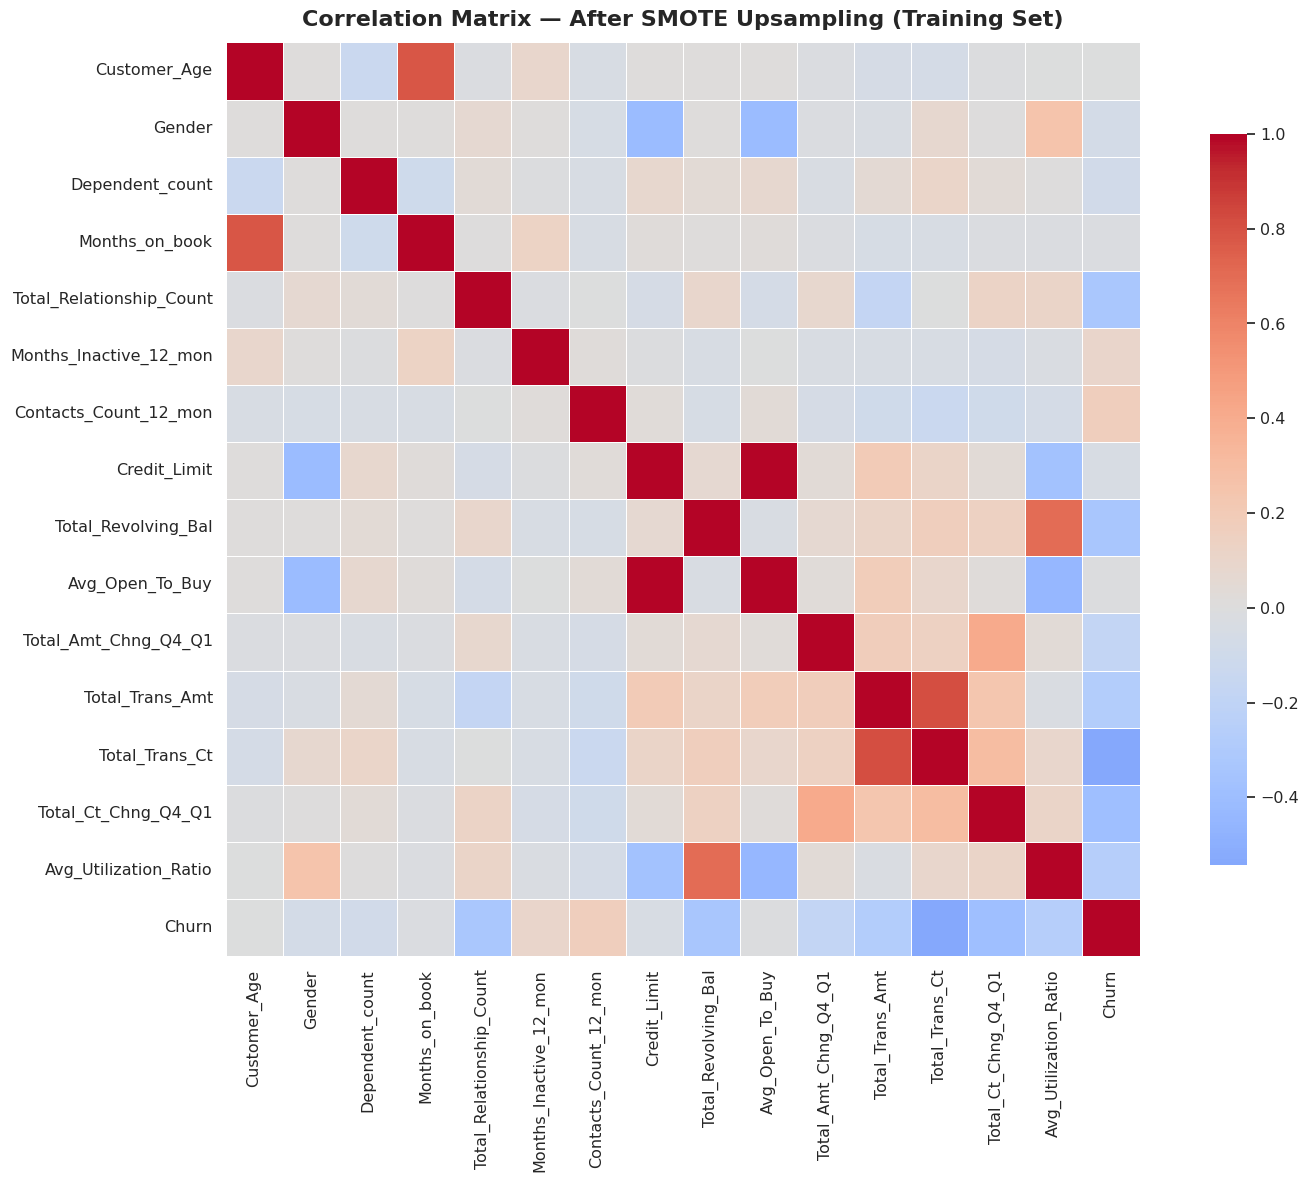

In [20]:
# Setup the figure canvas size
plt.figure(figsize=(16, 12))

# Calculate the post-SMOTE numeric correlation matrix (training data only)
corrmap = usampled_df.corr(numeric_only=True)

# Generate the heatmap with your styling parameters
sns.heatmap(
    corrmap,
    cmap="coolwarm",
    linewidths=0.5,
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)

# Apply header title, adjust padding layout, and display the plot
plt.title("Correlation Matrix — After SMOTE Upsampling (Training Set)", fontsize=16)
plt.tight_layout()
plt.show()

Observation: Post-SMOTE, correlation patterns in the training data are similar to the raw features, with `Attrition_Flag` correlations with `Total_Trans_Amt` and `Total_Trans_Ct` reinforced by the balanced training data.

### 4.3 Principal Component Analysis Of One-Hot Encoded Data

PCA is used to reduce the dimensionality of the one-hot encoded variables. It is **fit on the training OHE data only** (`ohe_data`) and then used to **transform** both the training and test OHE data, so no information from the test set leaks into the PCA transformation.

In [21]:
# Run your PCA code — fit on training data only
N_COMPONENTS = 4
pca_model = PCA(n_components=N_COMPONENTS, random_state=42)

pc_matrix_train = pca_model.fit_transform(ohe_data)
pc_matrix_test = pca_model.transform(ohe_data_test)

# View the shape of the newly compressed component matrices
print(f"Original shape (train): {ohe_data.shape}")
print(f"PCA reduced shape (train): {pc_matrix_train.shape}")
print(f"PCA reduced shape (test) : {pc_matrix_test.shape}")

# Check how much information was retained
explained_var = pca_model.explained_variance_ratio_.sum()
print(f"Total information (variance) retained: {explained_var * 100:.2f}%")

Original shape (train): (13598, 17)
PCA reduced shape (train): (13598, 4)
PCA reduced shape (test) : (2026, 4)
Total information (variance) retained: 49.67%


Concatenates the four principal components (named `PC-0` to `PC-3`) with the training and test sets respectively, creating `usampled_df_with_pcs` and `test_df_with_pcs`.

In [22]:
# Execute your consolidation line
pc_cols = ["PC-{}".format(i) for i in range(N_COMPONENTS)]

usampled_df_with_pcs = pd.concat(
    [usampled_df.reset_index(drop=True), pd.DataFrame(pc_matrix_train, columns=pc_cols)],
    axis=1,
)

test_df_with_pcs = pd.concat(
    [test_df.reset_index(drop=True), pd.DataFrame(pc_matrix_test, columns=pc_cols)],
    axis=1,
)

# View the unified dataset structure
print("Final Columns:")
print(usampled_df_with_pcs.columns.tolist())

Final Columns:
['Customer_Age', 'Gender', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Churn', 'PC-0', 'PC-1', 'PC-2', 'PC-3']


Generates a pairplot of the PCA components (training set), colored by `Churn` status, to visualize separation and total explained variance.

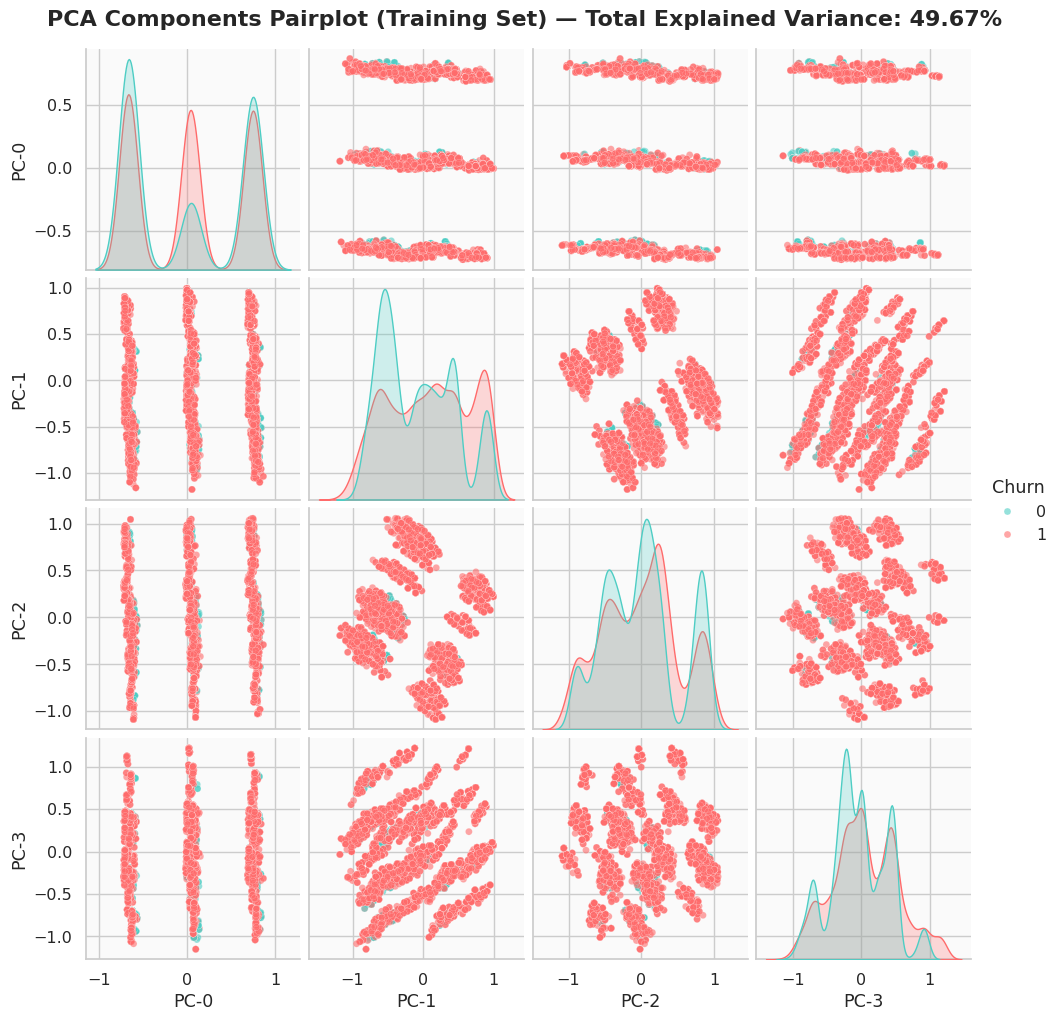

In [23]:
# Prepare the PCA dataframe (training set)
pca_cols = ['PC-{}'.format(i) for i in range(N_COMPONENTS)]
evr = pca_model.explained_variance_ratio_
total_var = evr.sum() * 100

g = sns.pairplot(
    usampled_df_with_pcs,
    hue='Churn',
    vars=pca_cols,
    palette={0: "#4ECDC4", 1: "#FF6B6B"},
    plot_kws={'alpha': 0.6, 's': 25, 'edgecolor': 'white', 'linewidth': 0.2},
    diag_kws={'fill': True},
)

g.fig.suptitle(f"PCA Components Pairplot (Training Set) — Total Explained Variance: {total_var:.2f}%", y=1.02, fontsize=16)
plt.show()

Observation: PCA pairplot shows significant variance explained by the first four components. While clusters overlap, the visual indicates churn is complex and not linearly separable by these components.

## 5. Model Selection And Evaluation

Defines `X_features` (including `Total_Trans_Ct` and the PCA components), then builds `X_train`/`y_train` from the SMOTE-balanced training set (`usampled_df_with_pcs`) and `X_test`/`y_test` from the untouched test set (`test_df_with_pcs`). The split already happened in section 4.1, before SMOTE, so no further splitting is needed here.

In [24]:
# Run your feature selection code
X_features = [
    "Total_Trans_Ct",
    "PC-3",
    "PC-1",
    "PC-0",
    "PC-2",
    "Total_Ct_Chng_Q4_Q1",
    "Total_Relationship_Count",
]

X_train = usampled_df_with_pcs[X_features]
y_train = usampled_df_with_pcs["Churn"]

X_test = test_df_with_pcs[X_features]
y_test = test_df_with_pcs["Churn"]

# Verify the final model matrices
print("--- MODEL INPUT MATRICES ---")
print(f"Training Features Matrix (X_train): {X_train.shape}")
print(f"Testing Features Matrix (X_test)  : {X_test.shape}")
print(f"\nTraining Labels (y_train) balance:\n{y_train.value_counts()}")
print(f"\nTesting Labels (y_test) balance:\n{y_test.value_counts()}")

--- MODEL INPUT MATRICES ---
Training Features Matrix (X_train): (13598, 7)
Testing Features Matrix (X_test)  : (2026, 7)

Training Labels (y_train) balance:
Churn
0    6799
1    6799
Name: count, dtype: int64

Testing Labels (y_test) balance:
Churn
0    1701
1     325
Name: count, dtype: int64


Initializes `StandardScaler` to standardize numerical features, `fit_transforms` training data (`X_train`), and `transforms` test data (`X_test`), setting mean to 0 and std dev to 1.

In [25]:
print(f"Mean of first feature before scaling: {X_train.iloc[:, 0].mean():.2f}")

# Initialize and run your scaling code
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Verify that the scaling transformed the data structures
print("\n--- AFTER STANDARDIZATION ---")
print(f"Scaled X_train Mean (should be ~0) : {X_train[:, 0].mean():.2f}")
print(f"Scaled X_train Std Dev (should be 1): {X_train[:, 0].std():.2f}")
print(f"Scaled X_test Shape                 : {X_test.shape}")

Mean of first feature before scaling: 56.32

--- AFTER STANDARDIZATION ---
Scaled X_train Mean (should be ~0) : 0.00
Scaled X_train Std Dev (should be 1): 1.00
Scaled X_test Shape                 : (2026, 7)


Trains a K-Nearest Neighbors (KNN) classifier (`n_neighbors=11`), makes predictions on the test set, and calculates its accuracy.

### 5.1 K-Nearest Neighbors (KNN)

In [26]:
# Execute your KNN modeling code
knn_model = KNeighborsClassifier(n_neighbors=11)
knn_model.fit(X_train, y_train)
predicted_y = knn_model.predict(X_test)
accuracy_knn = knn_model.score(X_test, y_test)

# Print the performance metric
print("KNN accuracy:", accuracy_knn)

KNN accuracy: 0.8583415597235933


Prints the classification report for the KNN model, detailing precision, recall, f1-score, and support.

In [27]:
print(classification_report(y_test, predicted_y))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91      1701
           1       0.55      0.66      0.60       325

    accuracy                           0.86      2026
   macro avg       0.74      0.78      0.76      2026
weighted avg       0.87      0.86      0.86      2026



Trains a Support Vector Classifier (SVC) with `probability=True`, makes predictions on the test set, and calculates its accuracy.

### 5.2 Support Vector Classifier (SVC)

In [28]:
# Execute your SVM modeling code
svc_model = SVC(random_state=1, probability=True)
svc_model.fit(X_train, y_train)
predict_y = svc_model.predict(X_test)
accuracy_svc = svc_model.score(X_test, y_test)

# Print the performance metric
print("SVM accuracy is :", accuracy_svc)

SVM accuracy is : 0.8504442250740375


Prints the classification report for the SVC model, providing detailed precision, recall, f1-score, and support metrics.

In [29]:
print(classification_report(y_test, predict_y))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1701
           1       0.53      0.68      0.59       325

    accuracy                           0.85      2026
   macro avg       0.73      0.78      0.75      2026
weighted avg       0.87      0.85      0.86      2026



Trains a Random Forest Classifier with specified hyperparameters, makes predictions on the test set, and prints its overall accuracy.

### 5.3 Random Forest Classifier

In [30]:
# Random Forest configuration
model_rf = RandomForestClassifier(
    n_estimators=500,
    oob_score=True,
    n_jobs=-1,
    random_state=50,
    max_features="sqrt",
    max_leaf_nodes=30,
)

# Train and predict
model_rf.fit(X_train, y_train)
prediction_test = model_rf.predict(X_test)

# Evaluate performance
print("Random Forest Accuracy:", metrics.accuracy_score(y_test, prediction_test))
print("Out-of-Bag (OOB) Score:", model_rf.oob_score_)

Random Forest Accuracy: 0.8553800592300099
Out-of-Bag (OOB) Score: 0.8782909251360494


Prints the classification report for the Random Forest model, detailing precision, recall, f1-score, and support for each class.

In [31]:
print(classification_report(y_test, prediction_test))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91      1701
           1       0.54      0.73      0.62       325

    accuracy                           0.86      2026
   macro avg       0.74      0.81      0.76      2026
weighted avg       0.88      0.86      0.86      2026



Visualizes the confusion matrix for the Random Forest classifier using a heatmap to show true positives, true negatives, false positives, and false negatives.

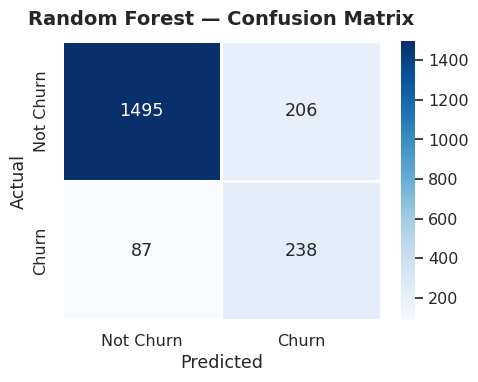

In [32]:
# Setup figure canvas size
plt.figure(figsize=(5, 4))

# Render the styled confusion matrix heatmap
sns.heatmap(
    confusion_matrix(y_test, prediction_test),
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=2,
    linecolor="white",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"],
)

# Apply axis labels and titles
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()


Observation: Random Forest confusion matrix indicates good performance with high true positives/negatives and low false positives/negatives, suggesting effective churn prediction.

Plots the Receiver Operating Characteristic (ROC) curve for the Random Forest model, evaluating its discriminative power.

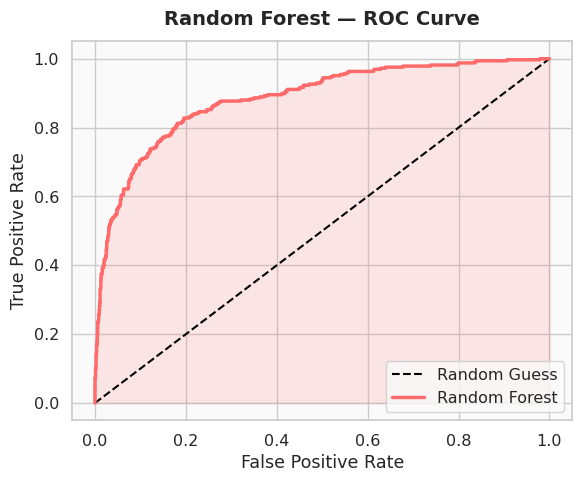

In [33]:
# Run your exact line to isolate column 1 (Probability of Churn)
y_rfpred_prob = model_rf.predict_proba(X_test)[:, 1]

# Compute the ROC boundary statistics
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_rfpred_prob)

# Setup canvas and plot elements
plt.figure(figsize=(6, 5))

# Baseline random chance line (diagonal)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

# Model performance line
plt.plot(fpr_rf, tpr_rf, label="Random Forest", color="#FF6B6B", linewidth=2.5)

# Fill the area under the curve (AUC visualizer)
plt.fill_between(fpr_rf, tpr_rf, alpha=0.15, color="#FF6B6B")

# Apply metadata labels and formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve", fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [34]:

#  View the full, 2-column probability output matrix
full_probabilities = model_rf.predict_proba(X_test)
# --- Visual Inspection of Results ---
print("--- PREDICT_PROBA STRUCTURES ---")
print("Raw matrix layout returned by .predict_proba() [First 5 rows]:")
print(full_probabilities[:5])
print("\nColumn 0: Probability of Staying (Not Churn)")
print("Column 1: Probability of Leaving (Churn)")

print("\n------------------------------------------------")
print("Your isolated 'y_rfpred_prob' array [First 5 rows]:")
print(y_rfpred_prob[:5])

--- PREDICT_PROBA STRUCTURES ---
Raw matrix layout returned by .predict_proba() [First 5 rows]:
[[0.83775404 0.16224596]
 [0.86508418 0.13491582]
 [0.33097986 0.66902014]
 [0.83942155 0.16057845]
 [0.88827195 0.11172805]]

Column 0: Probability of Staying (Not Churn)
Column 1: Probability of Leaving (Churn)

------------------------------------------------
Your isolated 'y_rfpred_prob' array [First 5 rows]:
[0.16224596 0.13491582 0.66902014 0.16057845 0.11172805]


Observation: The Random Forest ROC curve is significantly above the random guess line, indicating strong discriminative ability and effectiveness in distinguishing churned vs. non-churned customers.

Trains a Logistic Regression model, makes predictions on the test set, and prints its accuracy.

### 5.4 Logistic Regression

In [35]:
# Execute your Logistic Regression modeling code
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
accuracy_lr = lr_model.score(X_test, y_test)

# Print the performance metric
print("Logistic Regression accuracy is :", accuracy_lr)

Logistic Regression accuracy is : 0.8144126357354393


Prints the classification report for the Logistic Regression model, providing precision, recall, and f1-score for each class.

In [36]:
lr_pred= lr_model.predict(X_test)
report = classification_report(y_test,lr_pred)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      1701
           1       0.45      0.71      0.55       325

    accuracy                           0.81      2026
   macro avg       0.69      0.77      0.72      2026
weighted avg       0.86      0.81      0.83      2026



Visualizes the confusion matrix for the Logistic Regression model using a heatmap, showing classification counts for churn and non-churn classes.

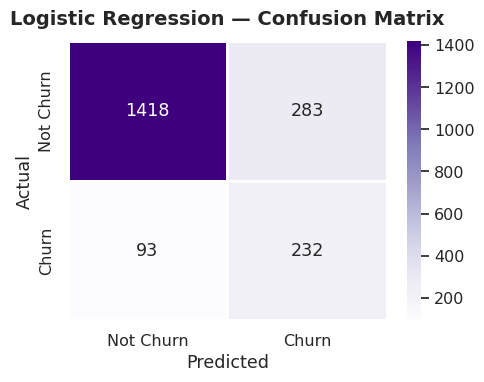

In [37]:
# Setup figure canvas size
plt.figure(figsize=(5, 4))

# Render the styled confusion matrix heatmap
sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Purples",  # Purple color spectrum
    linewidths=2,
    linecolor="white",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"],
)

# Apply axis labels and titles
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

Observation: Logistic Regression confusion matrix shows reasonable performance, but with more misclassifications than Random Forest, indicating room for improvement.

Plots the Receiver Operating Characteristic (ROC) curve for the Logistic Regression model to assess its ability to distinguish between churned and non-churned customers.

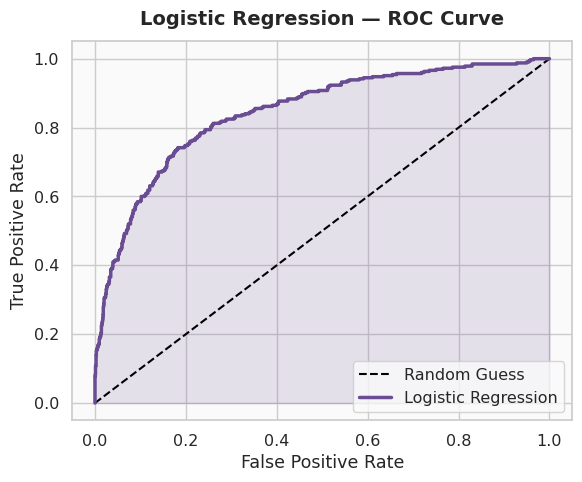

In [38]:
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.plot(fpr, tpr, label='Logistic Regression', color="#6A4C93", linewidth=2.5)
plt.fill_between(fpr, tpr, alpha=0.15, color="#6A4C93")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression — ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


Observation: Logistic Regression's ROC curve shows discriminative ability but is slightly less performant than Random Forest, suggesting lower overall power.

Initializes and trains a `VotingClassifier` ensemble model using SVC, Logistic Regression, Random Forest, and KNN with 'soft' voting. Makes predictions and prints the final accuracy.

### 5.5 Voting Classifier

In [39]:
from sklearn.ensemble import VotingClassifier

#  Assemble and train the Voting Classifier
clf1 = svc_model
clf2 = lr_model
clf3 = model_rf
clf4 = knn_model

eclf1 = VotingClassifier(
    estimators=[
        ("svc", clf1),
        ("lr", clf2),
        ("raforest", clf3),
        ("knn", clf4),
    ],
    voting="soft",
)
eclf1.fit(X_train, y_train)

# Generate predictions and evaluate performance
predictions = eclf1.predict(X_test)
print("Final Accuracy Score:")
print(metrics.accuracy_score(y_test, predictions))

Final Accuracy Score:
0.8543928923988154


Prints the classification report for the `VotingClassifier` ensemble model, evaluating precision, recall, and f1-score for each class.

In [40]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1701
           1       0.54      0.70      0.61       325

    accuracy                           0.85      2026
   macro avg       0.74      0.79      0.76      2026
weighted avg       0.87      0.85      0.86      2026



Visualizes the confusion matrix for the `VotingClassifier` ensemble model using a heatmap, showing true positives/negatives and false positives/negatives.

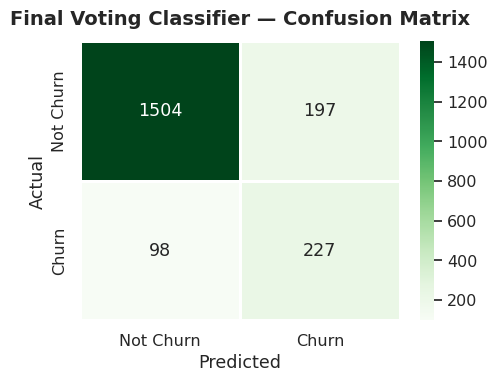

In [41]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, predictions),
            annot=True, fmt="d", cmap="Greens", linecolor="white", linewidths=2,
            xticklabels=["Not Churn", "Churn"], yticklabels=["Not Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Voting Classifier — Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()


Observation: The `VotingClassifier` confusion matrix shows good performance with high true positives/negatives and low false positives/negatives, demonstrating robust churn prediction.

### 5.6 Model Comparison and Final Result

--- Model Accuracy Comparison ---


,Model,Accuracy
0,KNN,0.8583
2,Random Forest,0.8554
4,Voting Classifier,0.8544
1,SVC,0.8504
3,Logistic Regression,0.8144


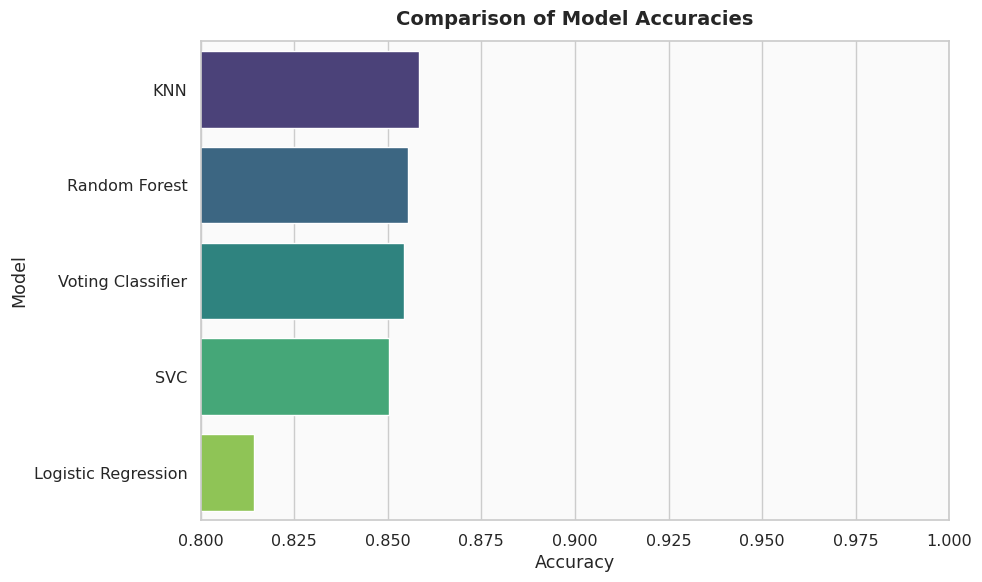

In [42]:
# Recalculate accuracies for models whose scores were only printed
rf_accuracy = model_rf.score(X_test, y_test)
voting_accuracy = eclf1.score(X_test, y_test)

# Create a DataFrame to compare accuracies
model_accuracies = pd.DataFrame({
    'Model': ['KNN', 'SVC', 'Random Forest', 'Logistic Regression', 'Voting Classifier'],
    'Accuracy': [accuracy_knn, accuracy_svc, rf_accuracy, accuracy_lr, voting_accuracy]
})

# Sort by accuracy for better comparison
model_accuracies = model_accuracies.sort_values(by='Accuracy', ascending=False)

print("--- Model Accuracy Comparison ---")
display(model_accuracies.round(4))

# Visualize the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=model_accuracies, palette='viridis')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Comparison of Model Accuracies')
plt.xlim(0.8, 1.0) # Set x-axis limit for better visualization of differences
plt.tight_layout()
plt.show()

Observation: KNN achieved the highest accuracy

### 5.7 Precision-Recall Trade-off & Threshold Tuning

All models above use the default 0.5 classification threshold. Because SMOTE trained the models on a 50/50 class balance while the real world (and this test set) is roughly 84/16, the models tend to over-predict churn — which pushes recall up but pulls precision down. This section plots the precision-recall trade-off for the Voting Classifier's churn probabilities and shows how precision, recall, and F1 shift as the decision threshold moves, so a threshold can be chosen deliberately instead of defaulting to 0.5.

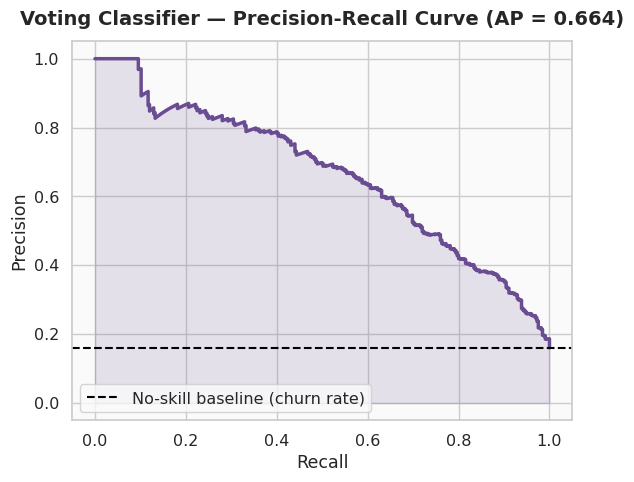

In [43]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score

# Use the Voting Classifier's predicted probability of churn (class 1)
y_scores = eclf1.predict_proba(X_test)[:, 1]

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, color="#6A4C93", linewidth=2.5)
plt.fill_between(recalls, precisions, alpha=0.15, color="#6A4C93")
plt.axhline(y=(y_test == 1).mean(), color="k", linestyle="--", label="No-skill baseline (churn rate)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Voting Classifier — Precision-Recall Curve (AP = {avg_precision:.3f})", fontsize=14)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

Observation: the curve shows the direct trade-off between catching more churners (higher recall) and keeping false alarms low (higher precision). The default threshold of 0.5 sits at one specific point on this curve — it is not necessarily the best point for the business goal.

In [44]:
# Sweep classification thresholds and see how precision/recall/F1 for the churn class respond
thresholds_to_test = np.arange(0.30, 0.75, 0.05)

rows = []
for t in thresholds_to_test:
    y_pred_t = (y_scores >= t).astype(int)
    rows.append({
        "Threshold": round(t, 2),
        "Precision (Churn)": precision_score(y_test, y_pred_t, pos_label=1),
        "Recall (Churn)": recall_score(y_test, y_pred_t, pos_label=1),
        "F1 (Churn)": f1_score(y_test, y_pred_t, pos_label=1),
        "Accuracy": (y_pred_t == y_test).mean(),
    })

threshold_df = pd.DataFrame(rows)
best_f1_row = threshold_df.loc[threshold_df["F1 (Churn)"].idxmax()]

print(f"Default threshold (0.50) vs. best-F1 threshold ({best_f1_row['Threshold']}):\n")
display(threshold_df.round(3))
print(f"\nBest F1 for the churn class is at threshold = {best_f1_row['Threshold']}")

Default threshold (0.50) vs. best-F1 threshold (0.6):



,Threshold,Precision (Churn),Recall (Churn),F1 (Churn),Accuracy
0,0.30,0.420,0.800,0.551,0.791
1,0.35,0.453,0.782,0.573,0.813
2,0.40,0.488,0.757,0.593,0.834
3,0.45,0.508,0.720,0.595,0.843
4,0.50,0.535,0.698,0.606,0.854
5,0.55,0.573,0.674,0.620,0.867
6,0.60,0.617,0.631,0.624,0.878
7,0.65,0.654,0.582,0.616,0.884
8,0.70,0.684,0.532,0.599,0.885



Best F1 for the churn class is at threshold = 0.6


Observation: raising the threshold above 0.5 trades some recall for higher precision (fewer false alarms), while lowering it does the opposite. Pick the threshold that matches the business cost: if a missed churner is costlier than a wasted retention outreach, favor recall (lower threshold); if outreach is expensive or limited, favor precision (higher threshold).

Customer churn significantly impacts profitability. Proactive strategies, including identifying at-risk customers, improving service, and building loyalty through personalized experiences, are crucial for retention. Analyzing reasons for churn can inform preventative measures.

<h1 style="background-color:orange;font-family:newtimeroman;font-size:300%;text-align:center;border-radius: 15px 50px;">END</h1>

Thank you for reading! 🙏
